In [2]:
import numpy as np
import cv2
from IPython.core.interactiveshell import InteractiveShell as IS
IS.ast_node_interactivity="all"
from config import *
import os
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn import datasets
plt.rcParams.update({
    'figure.dpi': 200,
    # 统一字体：SimHei支持中文，Times兼容英文负号（无冲突）
    'font.family': ['SimHei', 'Times New Roman'],
    'font.size': 20,
    'legend.fontsize': 18,
    'lines.linewidth': 5,
    'savefig.bbox': 'tight',
    # 核心：关闭Unicode负号，用ASCII减号（解决负号显示）
    'axes.unicode_minus': False
})

# SVD

## 图片压缩

In [3]:
img = cv2.imread('./data/pexels-irma-sjachlan1.jpg')
print('图片大小', img.shape)
# (1024*1281*3), 3表示RGB

def svd_compression(img, k):
    res_image = np.zeros_like(img)
    for i in range(img.shape[2]):
        # 进行奇异值分解, 从svd函数中得到的奇异值sigma 是从大到小排列的
        U, Sigma, VT = np.linalg.svd(img[:,:,i])
        res_image[:, :, i] = U[:,:k].dot(np.diag(Sigma[:k])).dot(VT[:k,:])
    return res_image
 
# 保留前k个奇异值
res1 = svd_compression(img, k=300)
res2 = svd_compression(img, k=200)
res3 = svd_compression(img, k=100)
res4 = svd_compression(img, k=50)
 
row11 = np.hstack((res1, res2))
row22 = np.hstack((res3, res4))
res = np.vstack((row11, row22))

图片大小 (397, 429, 3)


<Figure size 4000x4000 with 0 Axes>

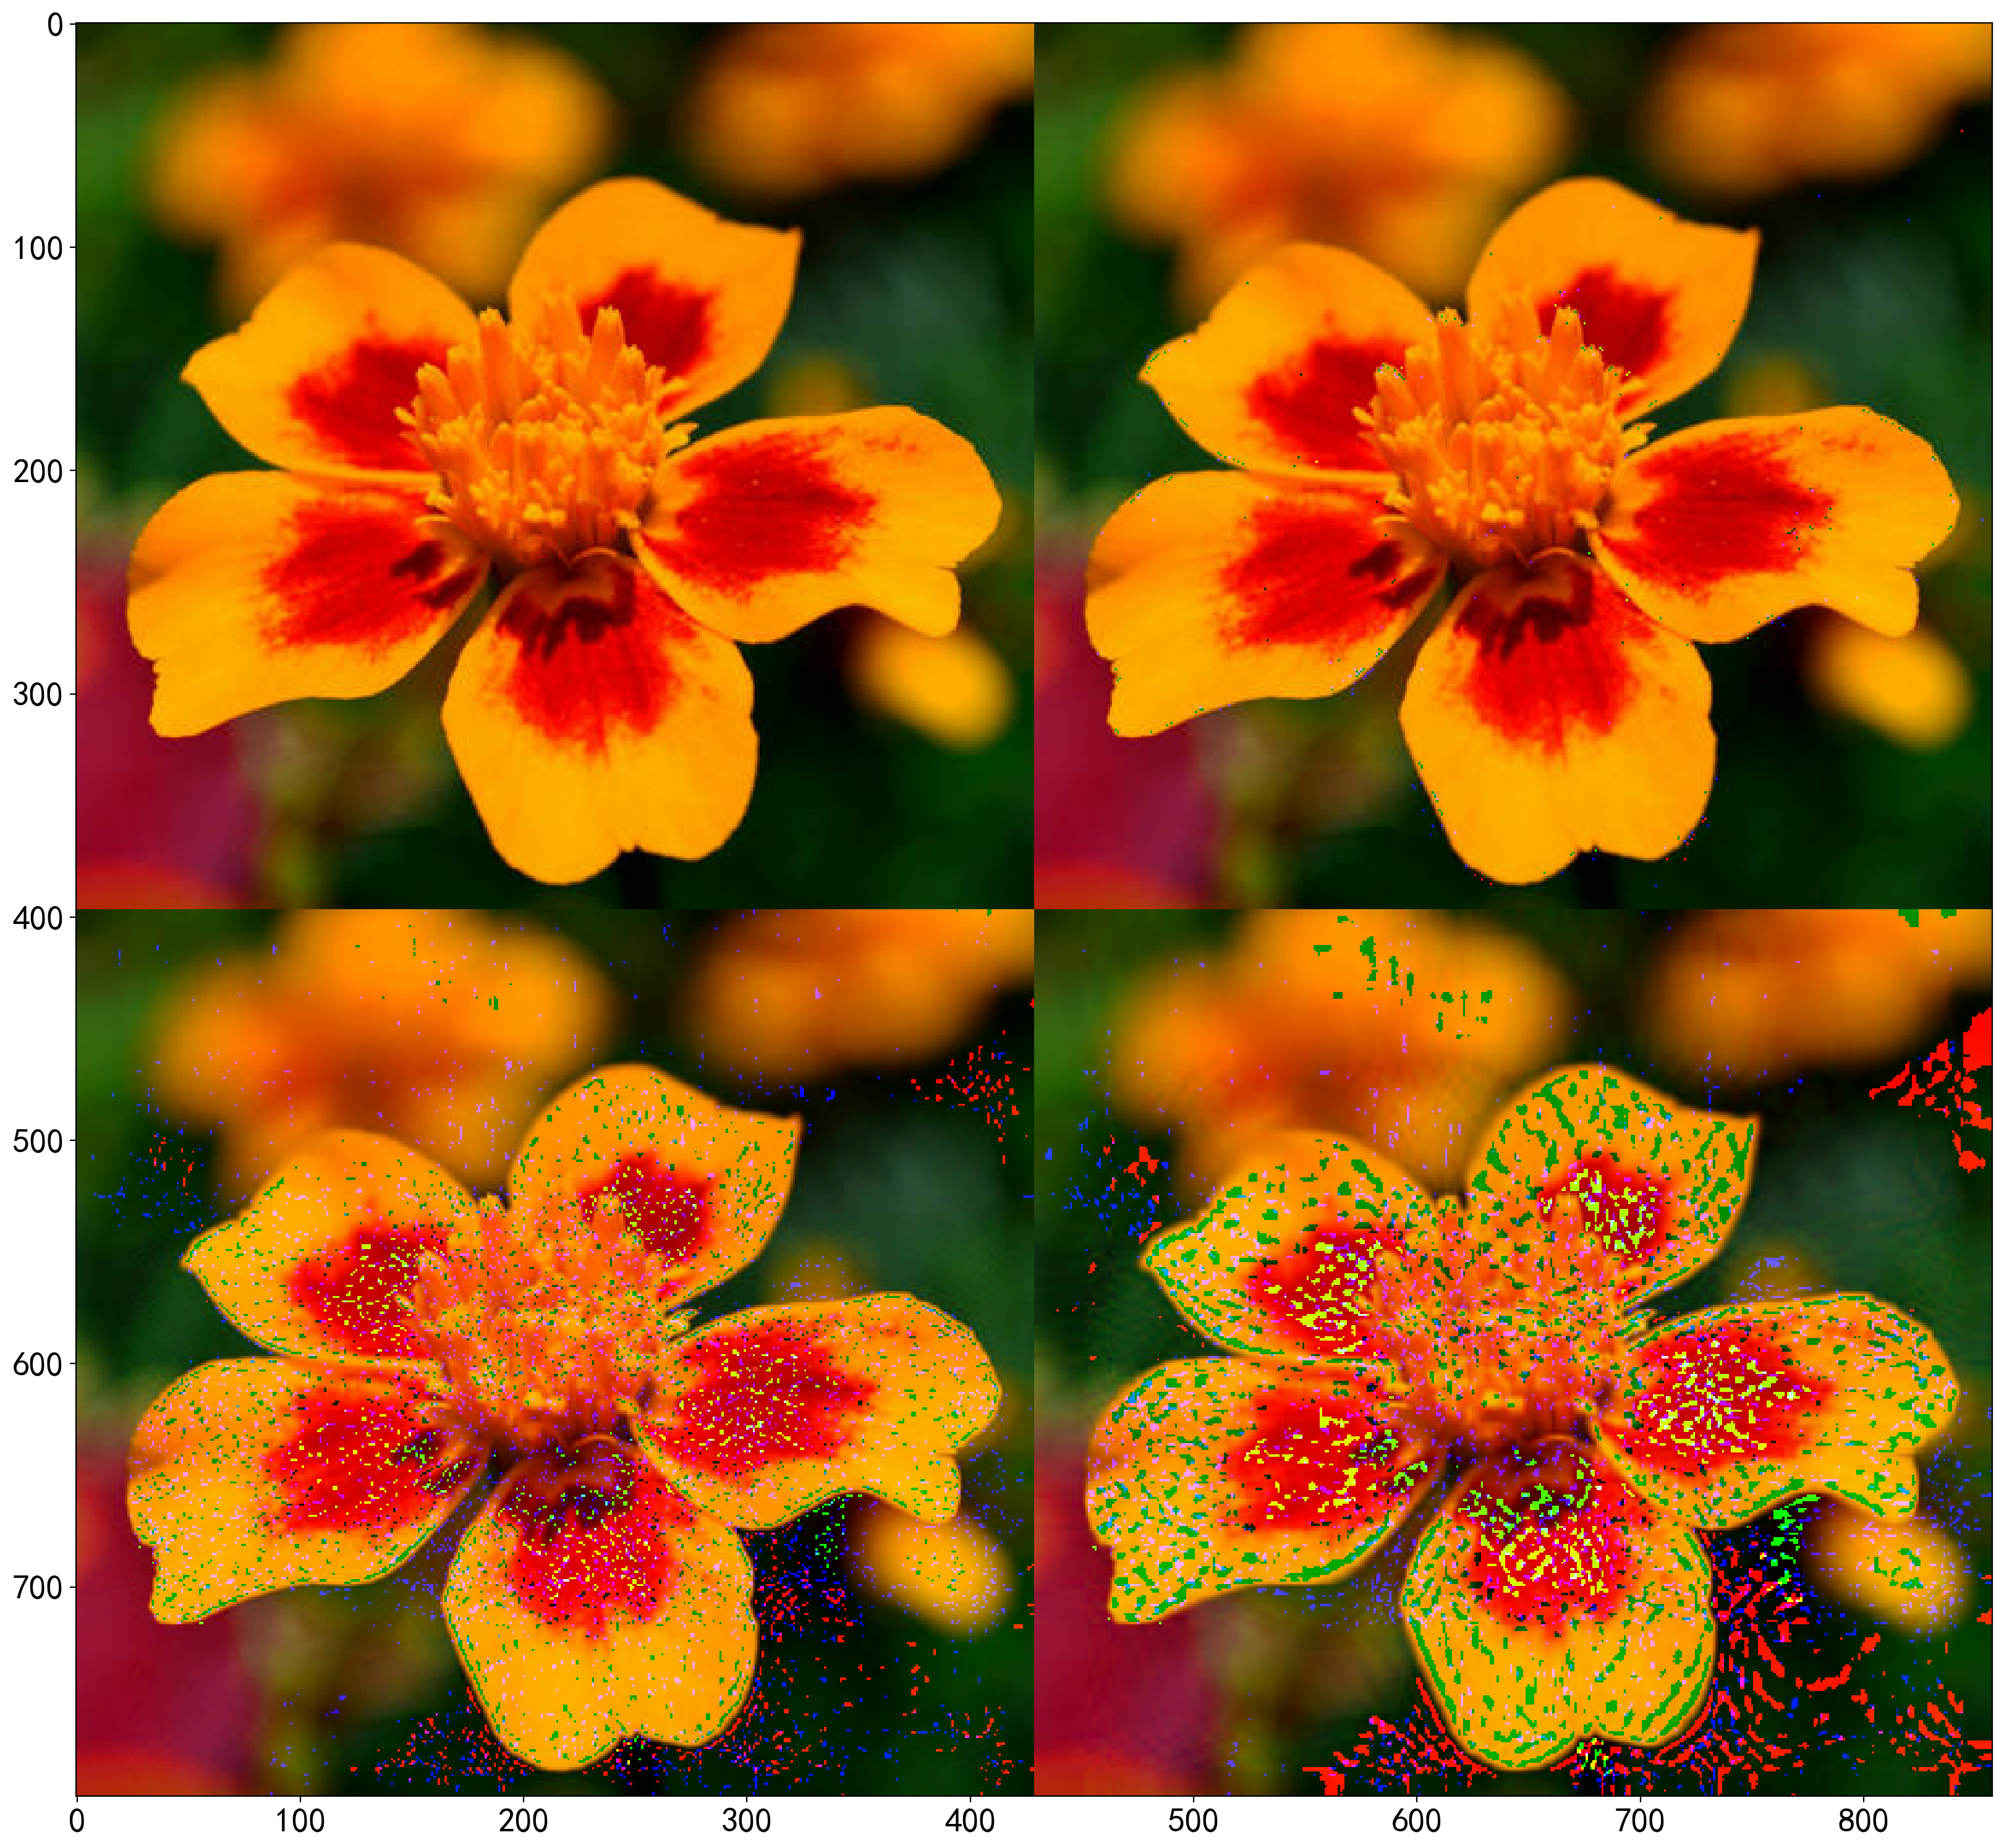

In [4]:
plt.figure(figsize=(20, 20))
plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))
plt.savefig(generateFilePath("picturede"))

# PCA降维

## 矩阵分解

In [5]:
k = 2  # 选取前两个主成分
X = np.array([[1, 2], [3, 4], [5, 6]])
X_mean = np.mean(X, axis=0)  # 求每个特征的均值
C = X - X_mean  # 去均值
V = np.cov(C.T)
eigenvalues, eigenvectors = np.linalg.eig(V)
sorted_indices = np.argsort(eigenvalues)[::-1]  # 从大到小排序
principal_components = eigenvectors[:, sorted_indices[:k]]
X_pca = C.dot(principal_components)
X_pca

array([[-2.82842712,  0.        ],
       [ 0.        ,  0.        ],
       [ 2.82842712,  0.        ]])

In [6]:
# 取均值的好处在于可以使用矩阵运算
np.cov(X.T)
X.T@X

np.cov(C.T)
C.T@C

array([[4., 4.],
       [4., 4.]])

array([[35, 44],
       [44, 56]])

array([[4., 4.],
       [4., 4.]])

array([[8., 8.],
       [8., 8.]])

## SVD降维

In [7]:
c = C/np.sqrt(C.shape[0]-1)
U, Sigma, VT = np.linalg.svd(c)
# U[:,:k].dot(np.diag(Sigma[:k])).dot(VT[:k,:])
X_svd = C.dot(VT[:k,:].T)
# 注意第二个成分的数值量级10^-16
X_svd

array([[-2.82842712e+00,  2.22044605e-16],
       [ 0.00000000e+00,  0.00000000e+00],
       [ 2.82842712e+00, -2.22044605e-16]])

In [8]:
# from sklearn.datasets import fetch_lfw_people
# faces = fetch_lfw_people(min_faces_per_person=60)

# 降维实例1

## PCA

<Figure size 2000x1200 with 0 Axes>

C:\Users\hyliu\AppData\Local\Temp\ipykernel_66748\2541551484.py:11: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_reduced[y==0, 0], X_reduced[y==0, 1], edgecolor='w', s=150, marker='x')


C:\Users\hyliu\AppData\Local\Temp\ipykernel_66748\2541551484.py:12: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_reduced[y==1, 0], X_reduced[y==1, 1], edgecolor='w', s=150, marker='+')


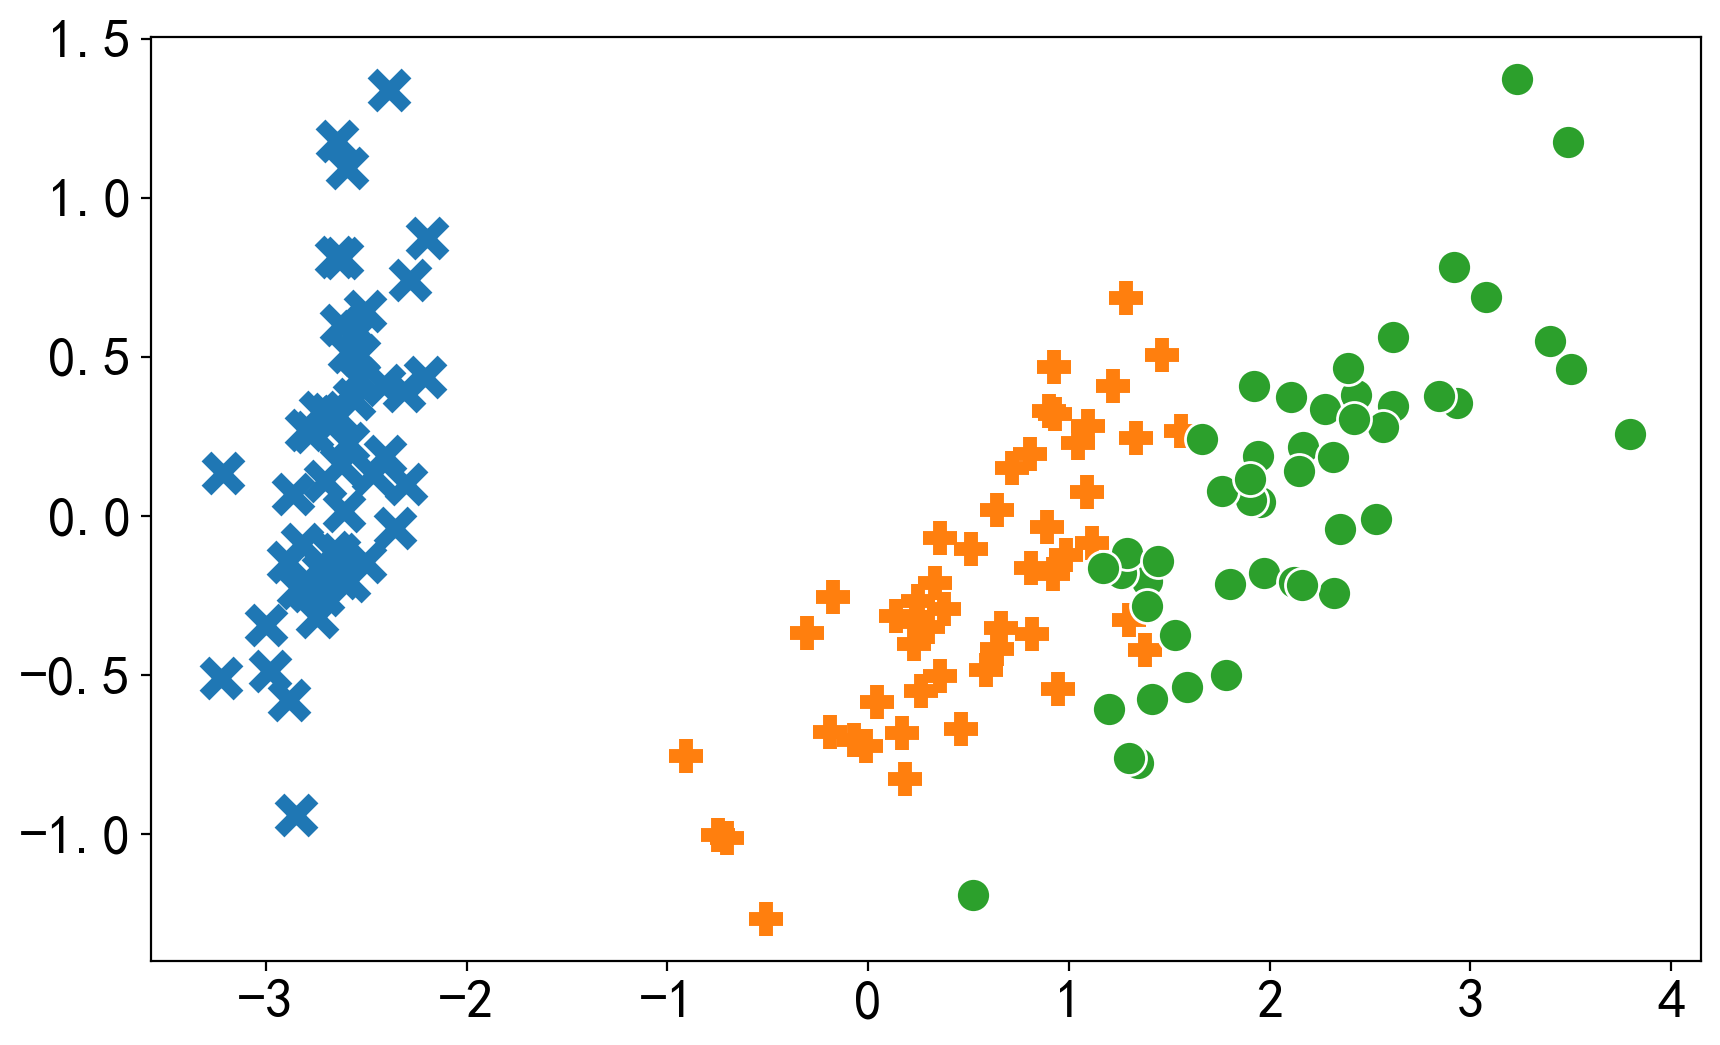

In [13]:
# iris
iris = datasets.load_iris()
X = iris.data
y = iris.target

# PCA
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

plt.figure(figsize=(10, 6))
plt.scatter(X_reduced[y==0, 0], X_reduced[y==0, 1], edgecolor='w', s=150, marker='x')
plt.scatter(X_reduced[y==1, 0], X_reduced[y==1, 1], edgecolor='w', s=150, marker='+')
plt.scatter(X_reduced[y==2, 0], X_reduced[y==2, 1], edgecolor='w', s=150, marker='o')
plt.savefig(generateFilePath('pca1'))

## SVD

<Figure size 2000x1200 with 0 Axes>

C:\Users\hyliu\AppData\Local\Temp\ipykernel_66748\4216978092.py:9: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_reduced[y==0, 0], X_reduced[y==0, 1], edgecolor='w', s=150, marker='x')


C:\Users\hyliu\AppData\Local\Temp\ipykernel_66748\4216978092.py:10: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_reduced[y==1, 0], X_reduced[y==1, 1], edgecolor='w', s=150, marker='+')


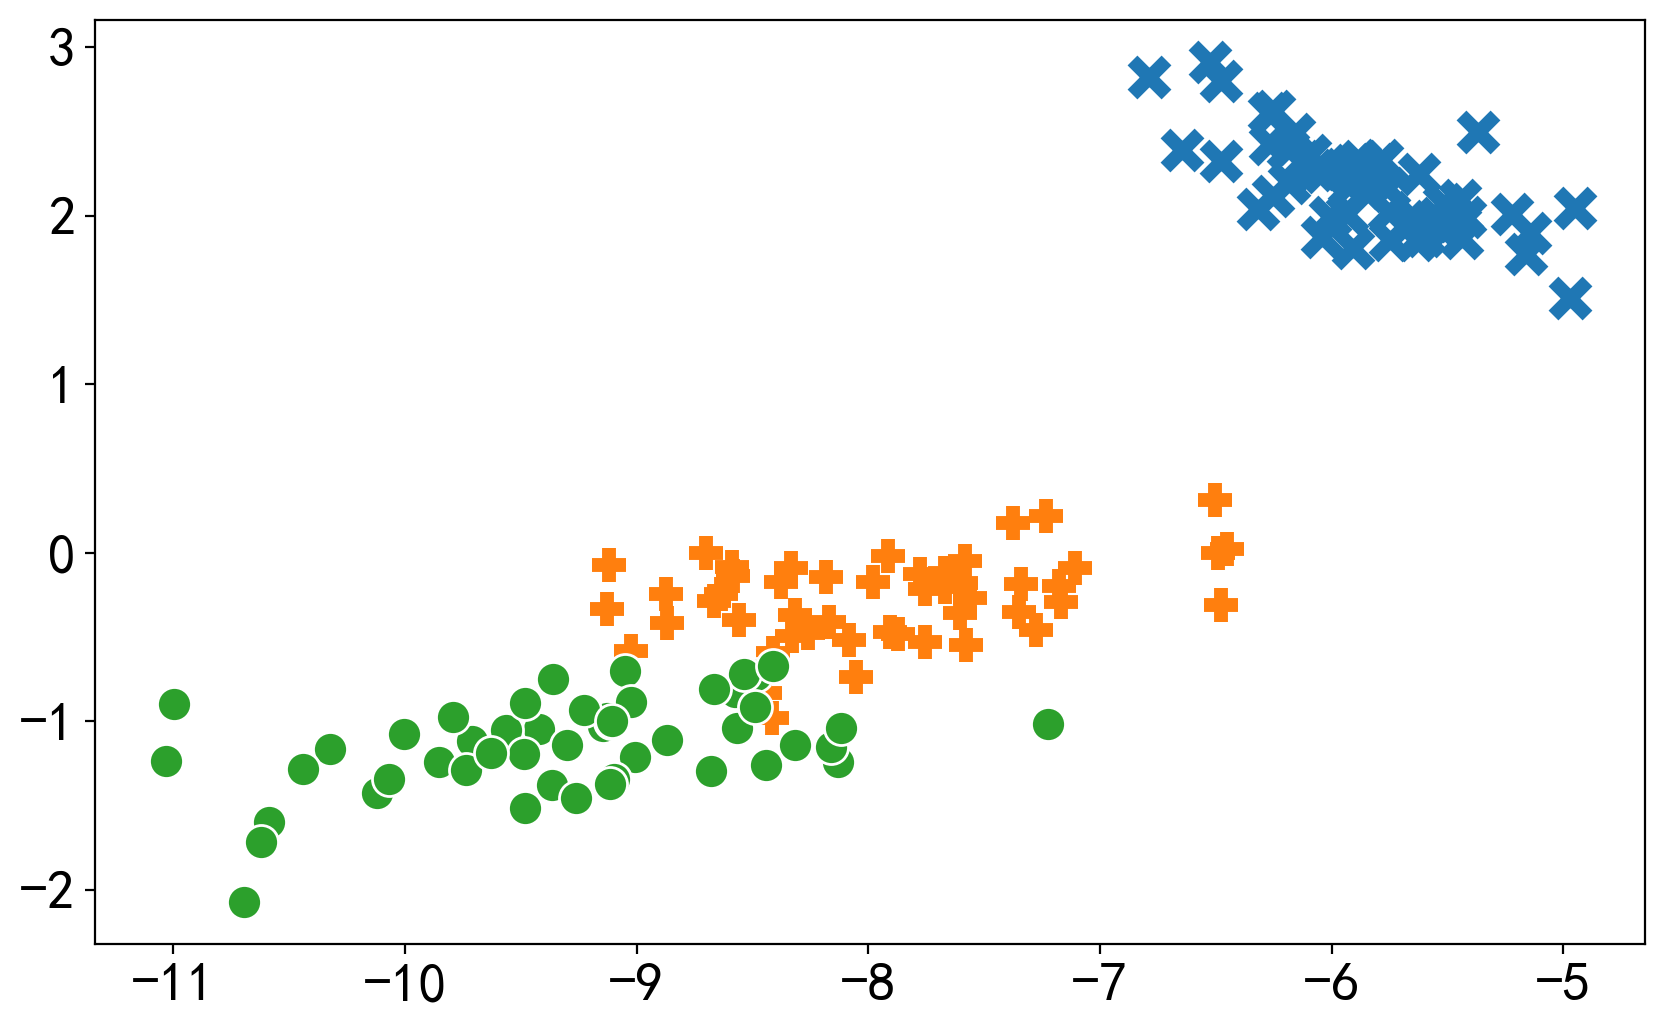

In [14]:
# SVD
U, s, VT = np.linalg.svd(X)
X_reduced = X.dot(VT[:2,:].T) 
# S = np.zeros((X.shape[0], X.shape[1]))
# S[:X.shape[1], :X.shape[1]] = np.diag(s)
# U[:, :2].dot(S[:2, :2])

plt.figure(figsize=(10, 6))
plt.scatter(X_reduced[y==0, 0], X_reduced[y==0, 1], edgecolor='w', s=150, marker='x')
plt.scatter(X_reduced[y==1, 0], X_reduced[y==1, 1], edgecolor='w', s=150, marker='+')
plt.scatter(X_reduced[y==2, 0], X_reduced[y==2, 1], edgecolor='w', s=150, marker='o')
plt.savefig(generateFilePath('svd1'))

## T-SNE

<Figure size 2000x1200 with 0 Axes>

C:\Users\hyliu\AppData\Local\Temp\ipykernel_66748\4122822583.py:6: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_reduced[y==0, 0], X_reduced[y==0, 1], edgecolor='w', s=150, marker='x')


C:\Users\hyliu\AppData\Local\Temp\ipykernel_66748\4122822583.py:7: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_reduced[y==1, 0], X_reduced[y==1, 1], edgecolor='w', s=150, marker='+')


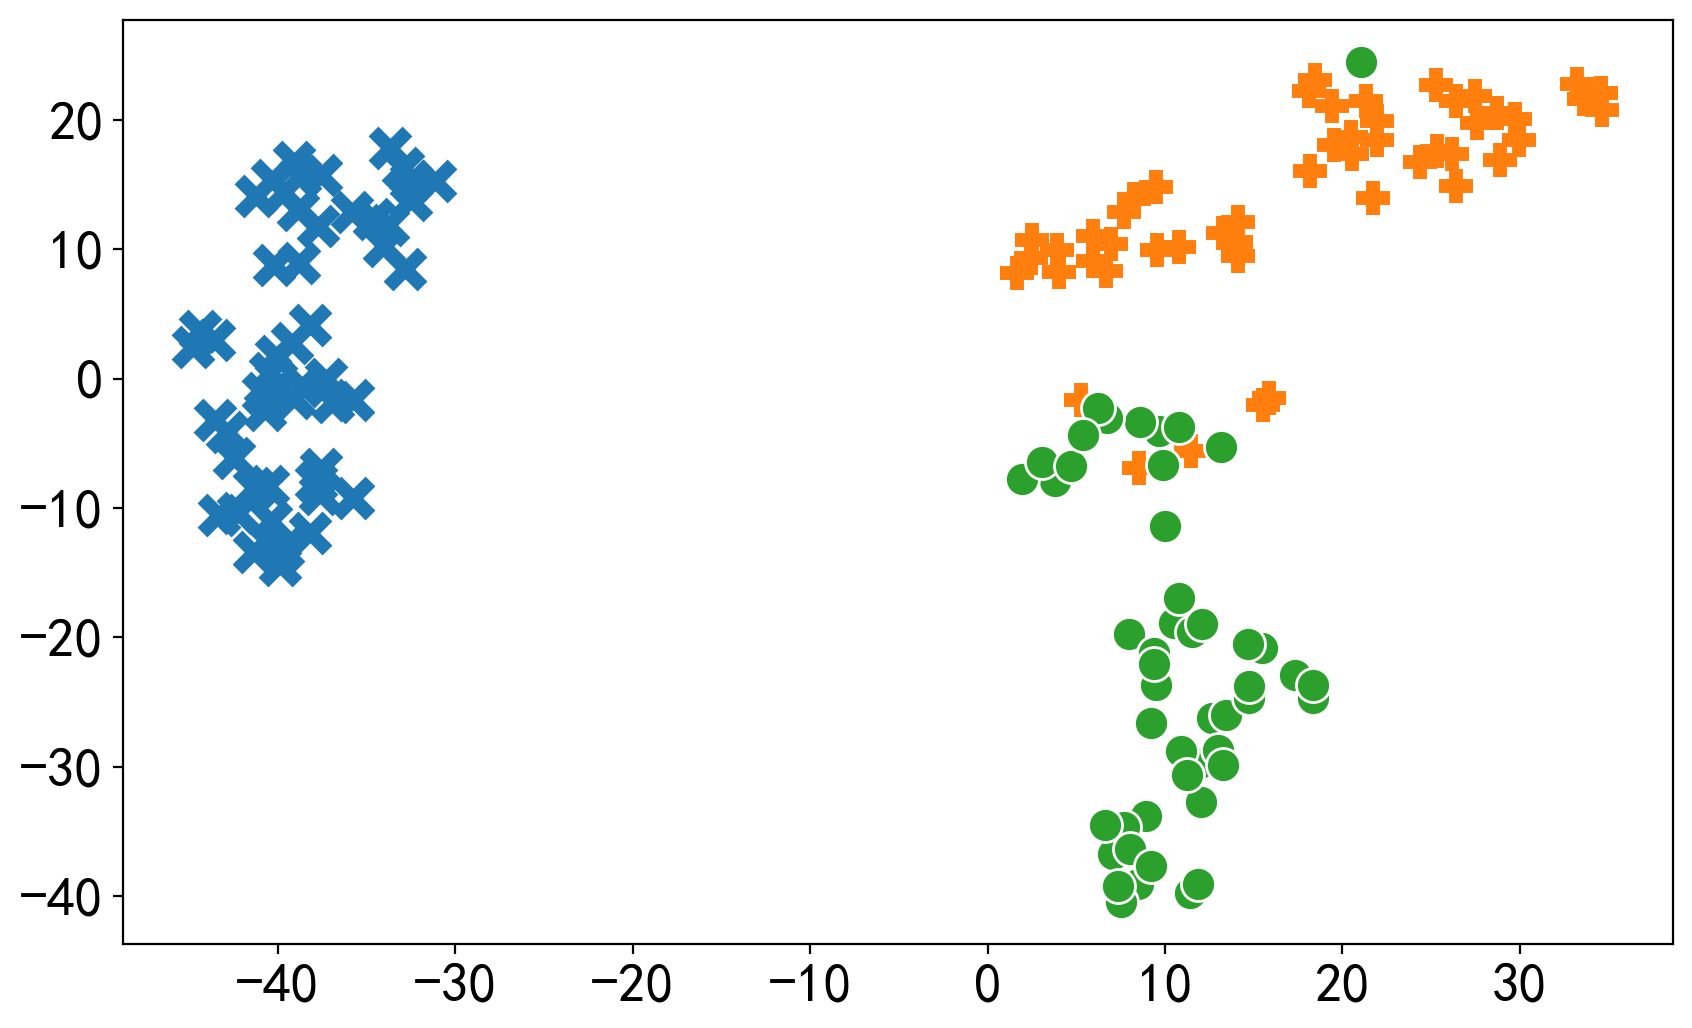

In [15]:
# T-SNE
model = TSNE(n_components=2, perplexity=8)
X_reduced = model.fit_transform(X)

plt.figure(figsize=(10, 6))
plt.scatter(X_reduced[y==0, 0], X_reduced[y==0, 1], edgecolor='w', s=150, marker='x')
plt.scatter(X_reduced[y==1, 0], X_reduced[y==1, 1], edgecolor='w', s=150, marker='+')
plt.scatter(X_reduced[y==2, 0], X_reduced[y==2, 1], edgecolor='w', s=150, marker='o')
plt.savefig(generateFilePath('tsne1'))

# 降维实例2

## 加载数据

In [13]:
data = pd.read_csv(f"./{prefix}clean_data.csv", parse_dates=[date_col])
df = data[data[date_col]=='2021-04-30'].reset_index(drop=True)
df.head()

,datetime,instrument,行业,1M,3M,5M,10M,换手率相对波动率,市净率,市现率,...,营业利润增速,营业收入增速,累计振动升降指标技术,股东权益比率,资金现金回收率,交易量波动率,成交量,振幅,换手率,市值
0,2021-04-30,000001.SZ,银行,-0.065289,-0.264463,-0.194215,-0.307025,-0.760508,-0.715480,-0.661839,...,-0.155305,-0.253301,-2.879738,-1.910580,-1.085132,-0.892965,2.988508,0.069248,-0.849078,2.125154
1,2021-04-30,000002.SZ,房地产,-0.108240,-0.258427,-0.317978,-0.232959,-0.723554,-0.731905,-0.400749,...,-0.145442,0.030250,-2.879738,-1.883657,-0.275748,-0.763107,2.988508,-1.045061,-0.802901,2.125154
2,2021-04-30,000004.SZ,计算机,0.157107,0.200125,0.046758,0.372818,0.525832,-0.599197,2.729929,...,2.105901,2.257934,-1.222422,1.543871,-0.899922,-0.647437,-0.619757,0.908605,-0.037256,-0.814874
3,2021-04-30,000005.SZ,公用事业,0.074286,0.365714,0.251429,0.280000,0.672376,-0.567701,0.235171,...,-1.957226,-1.339165,-1.128023,-0.109381,-0.502410,0.604914,-0.098383,-1.101415,-0.725505,-0.594829
4,2021-04-30,000006.SZ,房地产,-0.047529,-0.138783,-0.207224,-0.138783,-0.710645,-0.920516,-0.143263,...,-0.126723,-1.249434,-2.879738,-0.356910,-0.510070,-0.252890,-0.219453,-1.167332,-0.780266,0.411093


In [14]:
df.shape

(4267, 25)

In [15]:
factors_data = df[factors_lst]

## PCA

In [16]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(factors_data)

reduced_df_pca = pd.DataFrame(
    data=pca_data, columns=["Component 1", "Component 2"]
)

<Figure size 2000x1200 with 0 Axes>

C:\Users\hyliu\AppData\Local\Temp\ipykernel_42532\601008525.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


<Axes: xlabel='Component 1', ylabel='Component 2'>

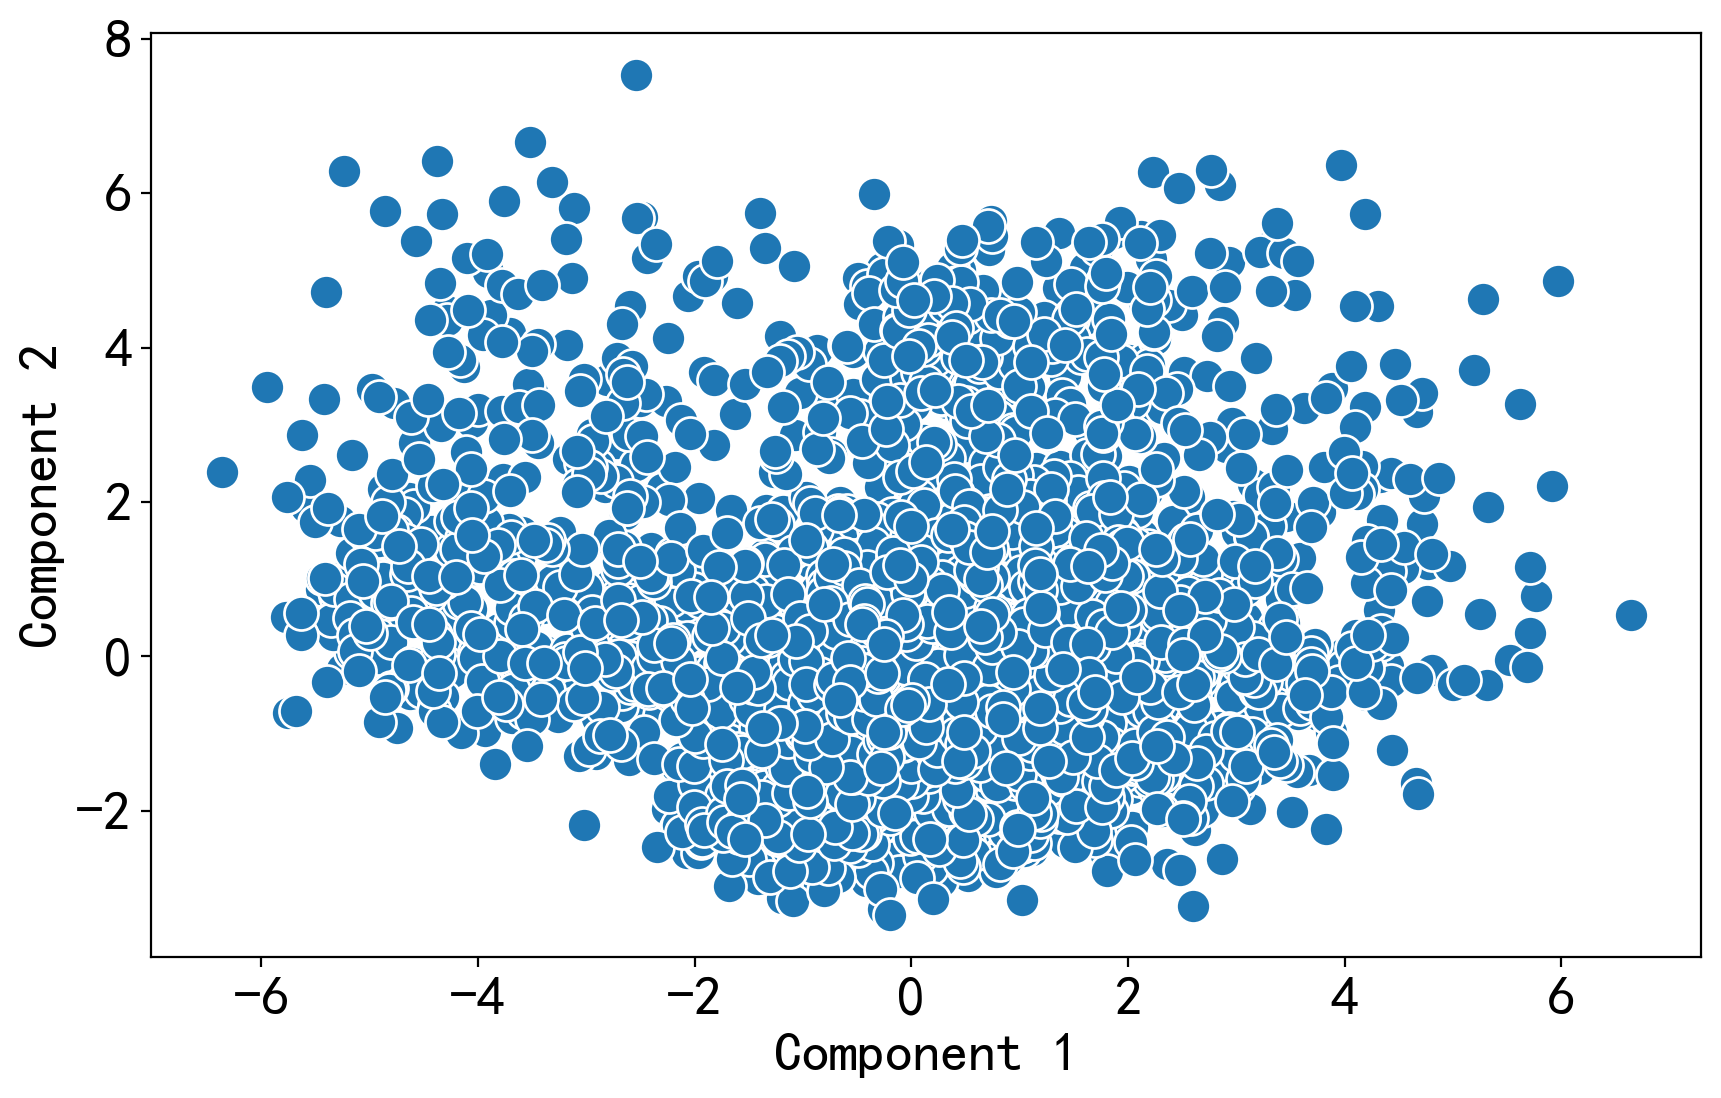

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=reduced_df_pca,
    x="Component 1",
    y="Component 2",
    # hue=df[industry],
    palette="rainbow",
    s=150
)
plt.savefig(generateFilePath('pca2'))

## svd

In [29]:
U, s, VT = np.linalg.svd(factors_data)

svd_data = factors_data.dot(VT[:2, :].T)
reduced_df_svd = pd.DataFrame(
    data=svd_data.values, columns=["Component 1", "Component 2"]
)

<Figure size 2000x1200 with 0 Axes>

C:\Users\hyliu\AppData\Local\Temp\ipykernel_42532\735147906.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


<Axes: xlabel='Component 1', ylabel='Component 2'>

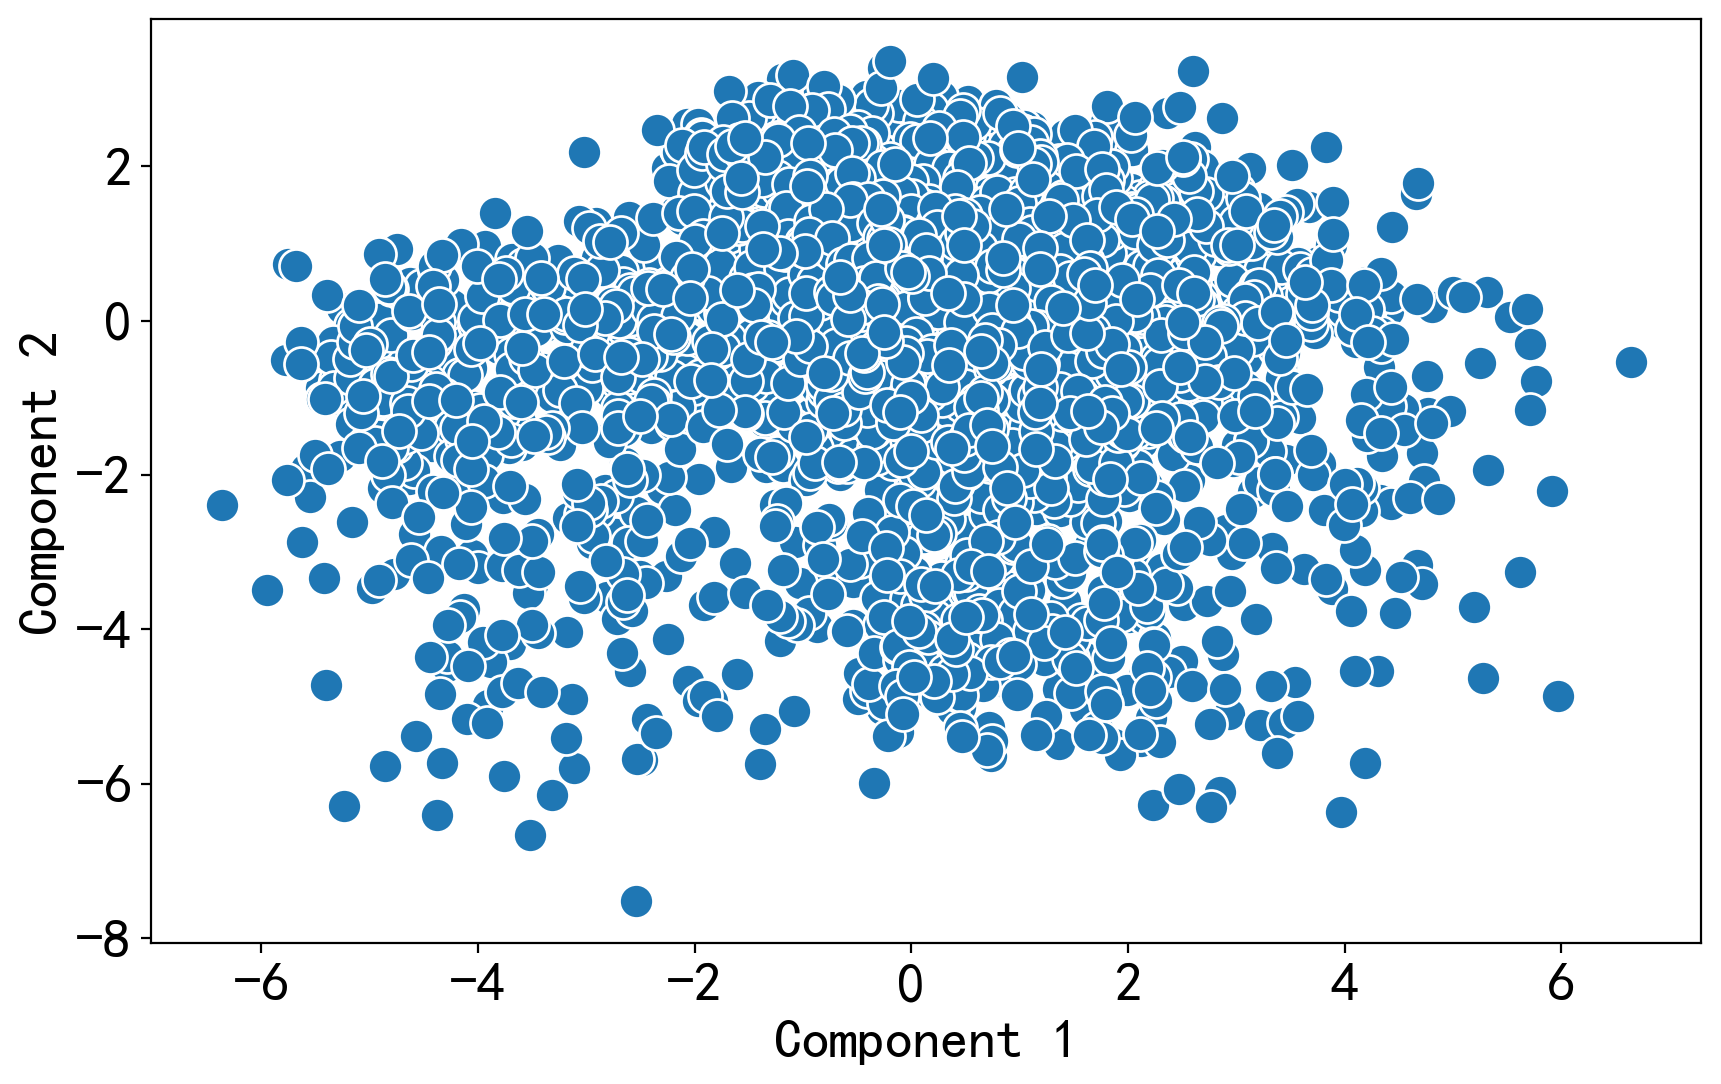

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=reduced_df_svd,
    x="Component 1",
    y="Component 2",
    # hue=df[industry],
    palette="rainbow",
    s=150
)
plt.savefig(generateFilePath('svd2'))

## tsne

In [31]:
model = TSNE(n_components=2, perplexity=10)
tsne_data = model.fit_transform(factors_data)
reduced_df_tsne = pd.DataFrame(
    data=tsne_data, columns=["Component 1", "Component 2"]
)

<Figure size 2000x1200 with 0 Axes>

C:\Users\hyliu\AppData\Local\Temp\ipykernel_42532\2472466828.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


<Axes: xlabel='Component 1', ylabel='Component 2'>

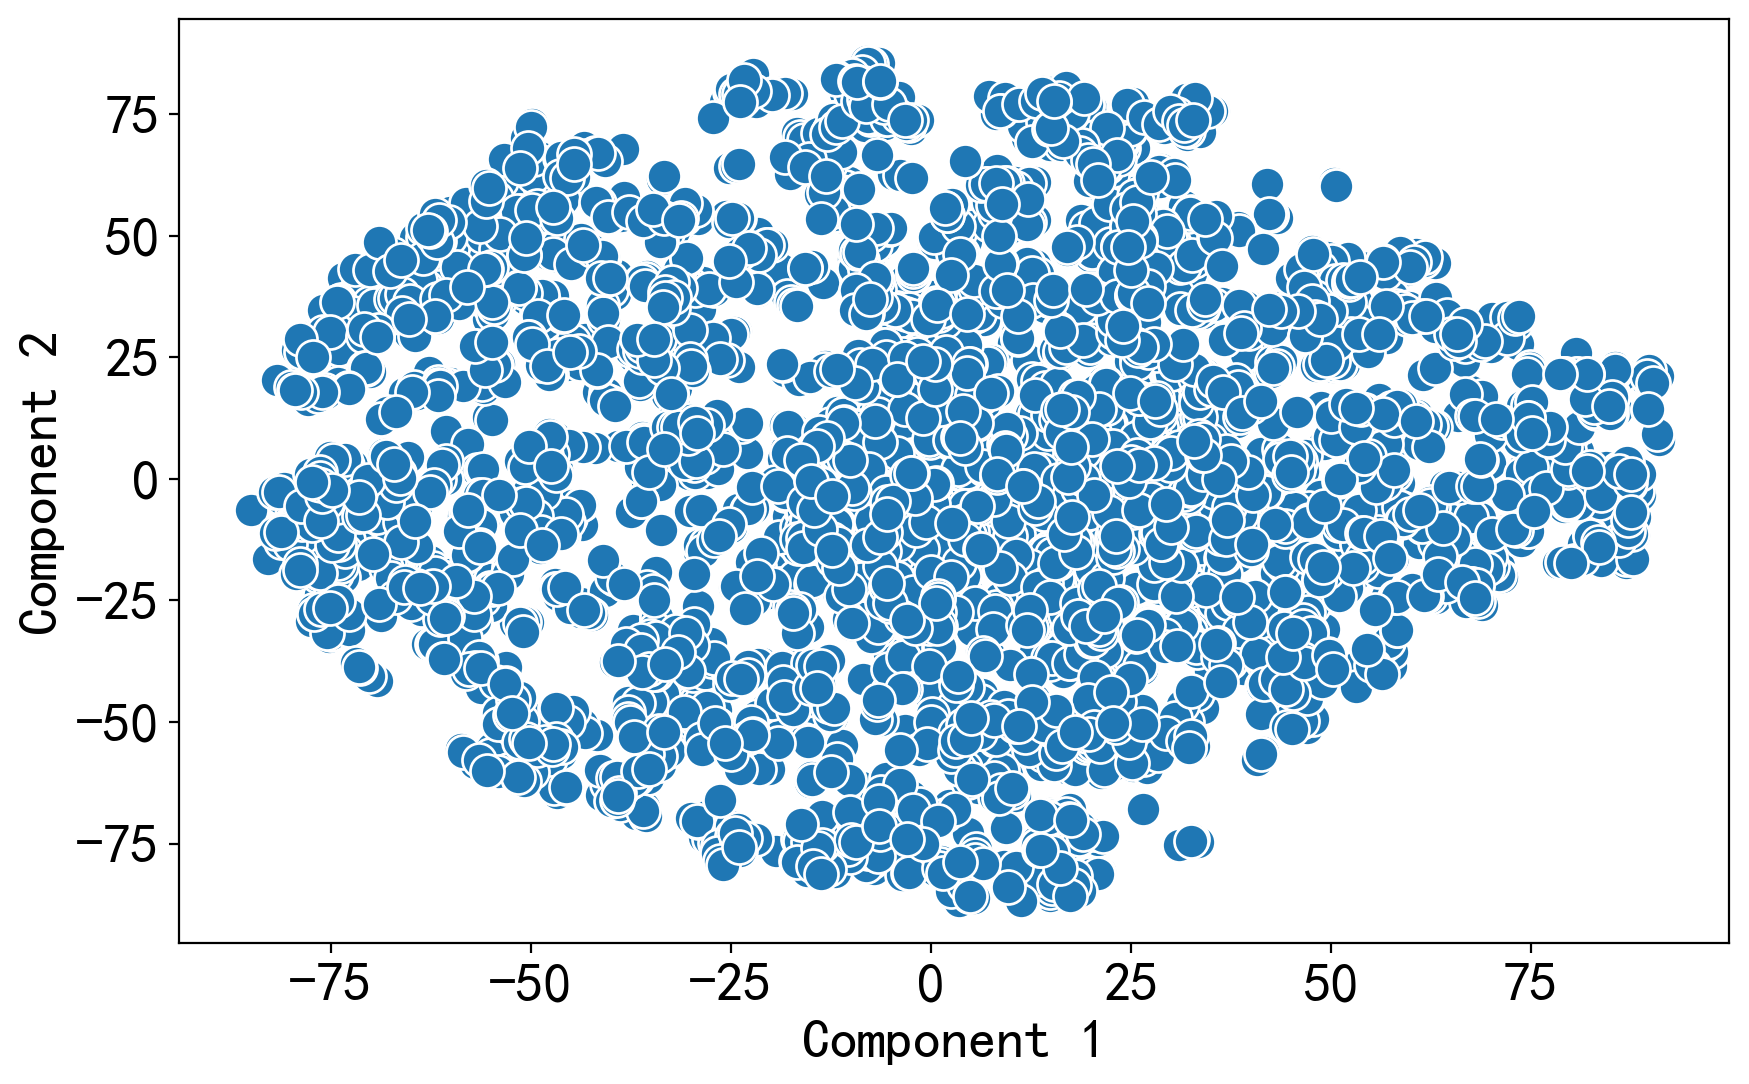

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=reduced_df_tsne,
    x="Component 1",
    y="Component 2",
    # hue=df[industry],
    palette="rainbow",
    s=150
)
plt.savefig(generateFilePath('tsne2'))